array([[<Axes: title={'center': 'LuasRumah'}>,
        <Axes: title={'center': 'JarakKeKota'}>],
       [<Axes: title={'center': 'UsiaRumah'}>,
        <Axes: title={'center': 'JumlahKamarTidur'}>],
       [<Axes: title={'center': 'SkorSekolah'}>, <Axes: >]], dtype=object)

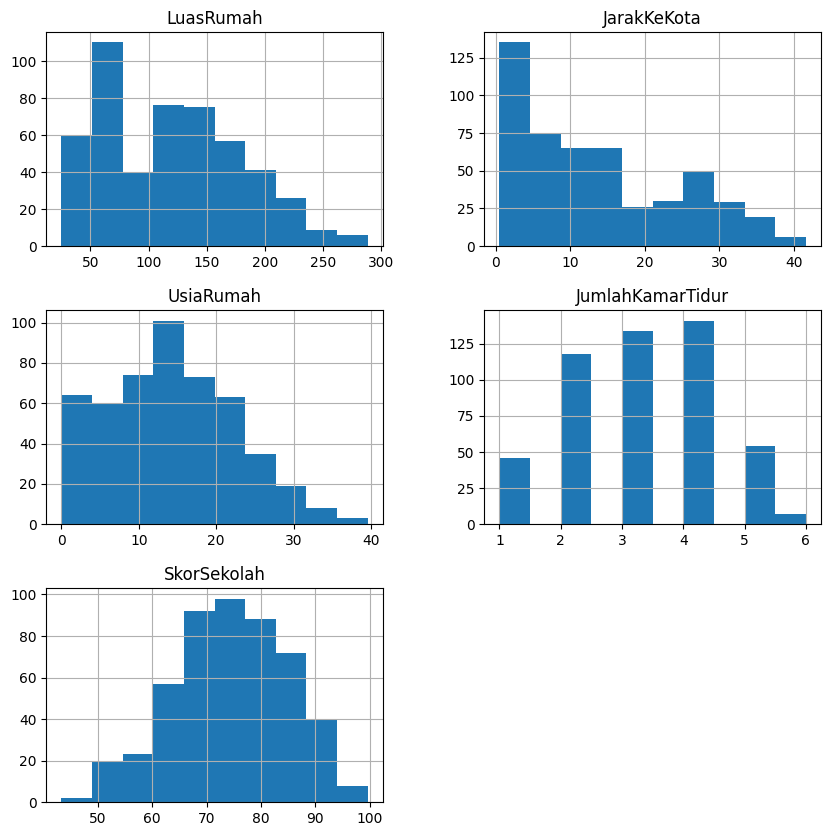

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv").set_index("Id")
df.hist(figsize=(10, 10))

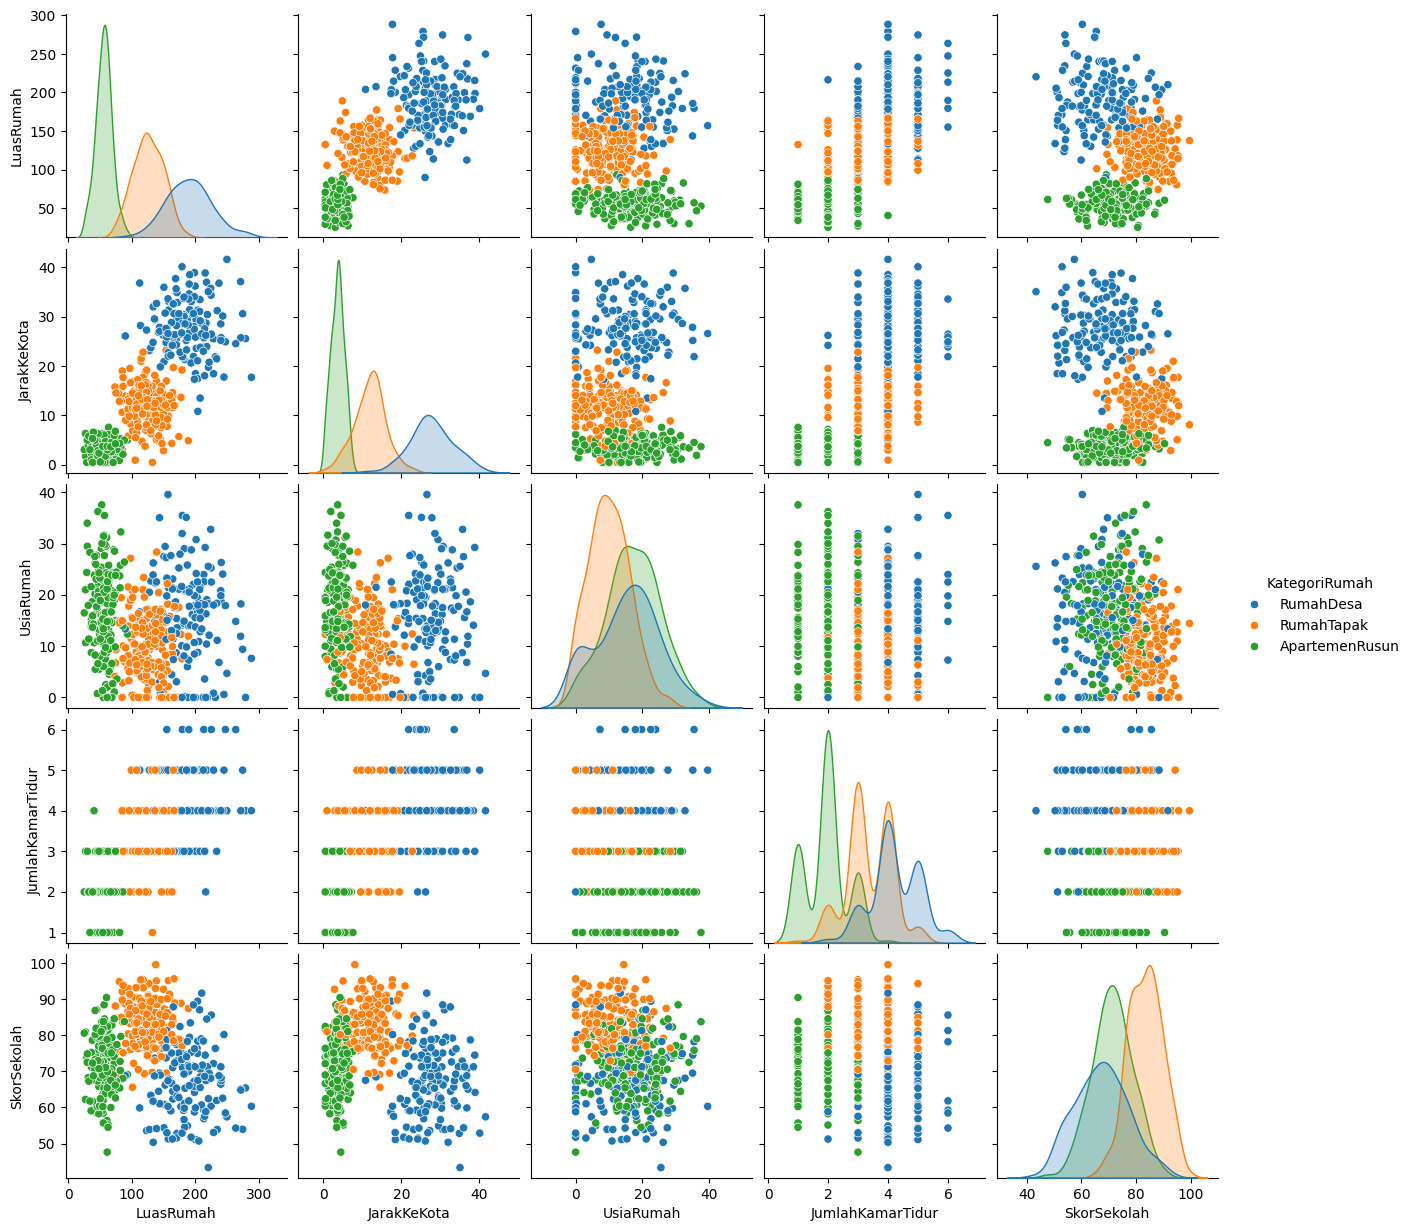

In [21]:
sns.pairplot(df, hue="KategoriRumah")

In [22]:
x, y = df.iloc[:, :-1].to_numpy(), df.iloc[:, -1].to_numpy()

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer, PolynomialFeatures
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("s1", StandardScaler()),
    ("pt", PowerTransformer(method="yeo-johnson")),
    ("s2", StandardScaler()),
    ("pf", PolynomialFeatures(degree=2)),
    ("s3", StandardScaler()),
    ("vt", VarianceThreshold()),
    ("skb", SelectKBest(score_func=f_classif, k=20)),
    # ("knc", KNeighborsClassifier(n_neighbors=5)),
    ("lr", LogisticRegression()),
])
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=67)

gscv = GridSearchCV(
    estimator=pipe,
    param_grid={
        "skb__k": [19],
        "lr__C": [42.81332398719393],
        # "knc__n_neighbors": [5],
    },
    cv=skf
)
gscv.fit(x, y)

bestmodel = gscv.best_estimator_

print(gscv.best_params_)
print(gscv.best_score_)

{'lr__C': 42.81332398719393, 'skb__k': 19}
0.99


In [37]:
dfx = pd.read_csv("test.csv").set_index("Id")
xsub = dfx.to_numpy()
ysub = bestmodel.predict(xsub)

dfy = pd.Series(ysub, index=dfx.index, name="KategoriRumah")
dfy.to_csv("submission.csv")

dfy

Id
501     ApartemenRusun
502         RumahTapak
503          RumahDesa
504         RumahTapak
505         RumahTapak
             ...      
996         RumahTapak
997          RumahDesa
998     ApartemenRusun
999          RumahDesa
1000         RumahDesa
Name: KategoriRumah, Length: 500, dtype: str